# 01_entropy_intro_codes.ipynb

本 notebook 生成第 1 篇推文所需的插图和示例数据。

输出文件：

- `./figs/entropy_intro_fig01_self_information.png`
- `./figs/entropy_intro_fig02_binary_entropy.png`
- `./figs/entropy_intro_fig03_coin_examples.png`
- `./data/entropy_intro_coin_examples.csv`


In [29]:
import os
from pathlib import Path
import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.lines import Line2D

warnings.filterwarnings('ignore')

# 创建输出文件夹：figs 存放插图，data 存放模拟数据或示例数据
FIG_DIR = Path('./figs')
DATA_DIR = Path('./data')
FIG_DIR.mkdir(exist_ok=True)
DATA_DIR.mkdir(exist_ok=True)

# ── Matplotlib 中文字体与通用样式 ──────────────────────────────
# Windows 本地优先使用 SimHei；Linux/macOS 环境下尝试注册 Noto CJK 字体文件。
# 注意：标题中的 log_2 不使用 Unicode 下标，而使用 mathtext，避免出现底数乱码。
import matplotlib.font_manager as fm

if platform.system() == 'Windows':
    FONT_FAMILY = 'SimHei'
else:
    font_candidates = [
        '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc',
        '/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc',
        '/usr/share/fonts/truetype/wqy/wqy-microhei.ttc',
        '/System/Library/Fonts/PingFang.ttc',
    ]
    FONT_FAMILY = 'DejaVu Sans'
    for font_path in font_candidates:
        if Path(font_path).exists():
            fm.fontManager.addfont(font_path)
            FONT_FAMILY = fm.FontProperties(fname=font_path).get_name()
            break

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [FONT_FAMILY, 'SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 240,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.22,
})

# 统一色板。为了便于后续维护，所有图片尽量使用同一组颜色。
COLORS = {
    'blue':   '#2C7FB8',
    'green':  '#41AB5D',
    'orange': '#F28E2B',
    'red':    '#D95F5F',
    'purple': '#7B6FD6',
    'gray':   '#666666',
    'light':  '#F5F7FA',
    'dark':   '#263238',
}

def savefig(name, tight=True):
    """统一保存图片，避免每个代码块重复写路径。"""
    path = FIG_DIR / name
    if tight:
        plt.tight_layout()
    plt.savefig(path, bbox_inches='tight')
    plt.show()
    print(f'已保存: {path}')


In [30]:
# 定义单个事件的信息量和熵函数。
# 这里默认使用 log2，因此单位是 bits。
def self_information(p):
    """单个事件的信息量 h(x) = -log2 p(x)。"""
    p = np.asarray(p)
    return -np.log2(p)

def entropy(prob):
    """离散概率分布的 Shannon entropy。"""
    prob = np.asarray(prob, dtype=float)
    prob = prob[prob > 0]
    return -np.sum(prob * np.log2(prob))

def binary_entropy(p):
    """二分类分布 (p, 1-p) 的熵。"""
    p = np.asarray(p, dtype=float)
    out = np.zeros_like(p)
    mask = (p > 0) & (p < 1)
    out[mask] = -(p[mask] * np.log2(p[mask]) + (1 - p[mask]) * np.log2(1 - p[mask]))
    return out


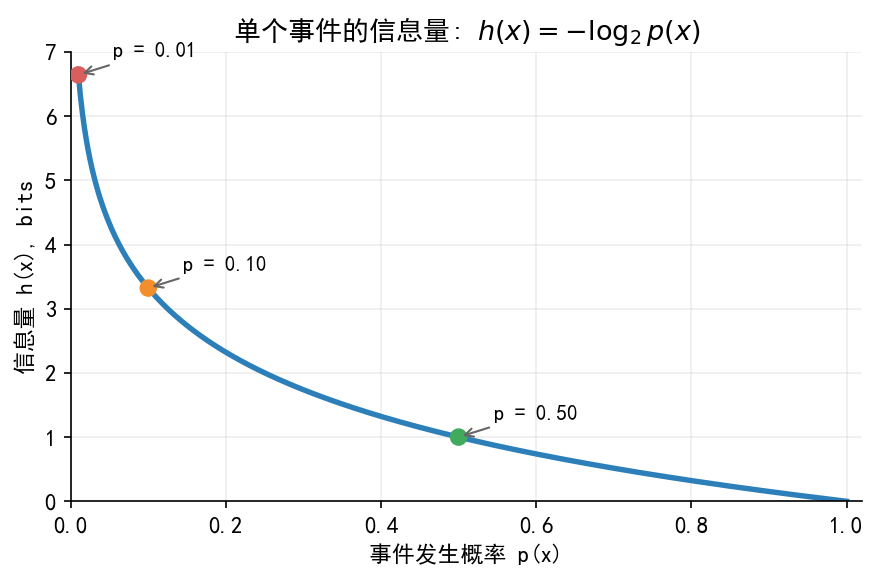

已保存: figs\entropy_intro_fig01_self_information.png


In [34]:
# 图 1：事件概率越低，单个事件的信息量越高
p = np.linspace(0.01, 1, 400)
h = self_information(p)

fig, ax = plt.subplots(figsize=(6.0, 4.0))
ax.plot(p, h, lw=2.6, color=COLORS['blue'])
ax.scatter([0.50, 0.10, 0.01], self_information([0.50, 0.10, 0.01]),
           s=55, color=[COLORS['green'], COLORS['orange'], COLORS['red']], zorder=3)

for px, label in [(0.50, 'p = 0.50'), (0.10, 'p = 0.10'), (0.01, 'p = 0.01')]:
    ax.annotate(label,
                xy=(px, self_information(px)),
                xytext=(px + 0.045, self_information(px) + 0.28),
                arrowprops=dict(arrowstyle='->', lw=1, color=COLORS['gray']),
                fontsize=10)

ax.set_title(r'单个事件的信息量: $h(x)=-\log_2 p(x)$')
ax.set_xlabel('事件发生概率 p(x)')
ax.set_ylabel('信息量 h(x), bits')
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 7)
savefig('entropy_intro_fig01_self_information.png')


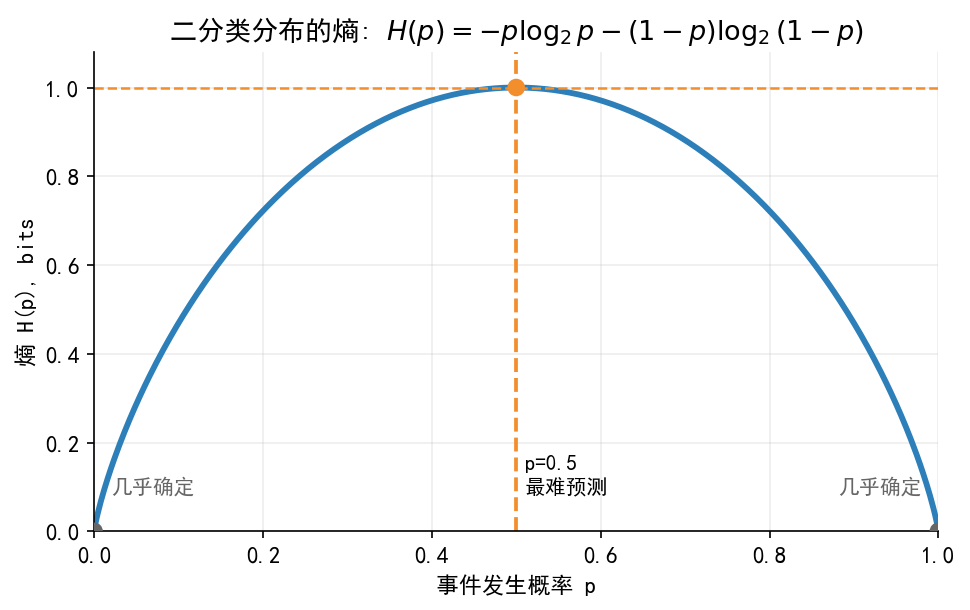

已保存: figs\entropy_intro_fig02_binary_entropy.png


In [32]:
# 图 2：二分类熵曲线，p=0.5 时不确定性最大
p = np.linspace(0, 1, 501)
H = binary_entropy(p)

fig, ax = plt.subplots(figsize=(6.6, 4.2))
ax.plot(p, H, lw=2.8, color=COLORS['blue'])
ax.axvline(0.5, color=COLORS['orange'], lw=1.8, ls='--')
ax.axhline(1.0, color=COLORS['orange'], lw=1.2, ls='--')
ax.scatter([0, 0.5, 1], [0, 1, 0], s=55, color=[COLORS['gray'], COLORS['orange'], COLORS['gray']], zorder=3)

ax.text(0.51, 0.08, 'p=0.5\n最难预测', ha='left', va='bottom', fontsize=10)
ax.text(0.02, 0.08, '几乎确定', ha='left', va='bottom', fontsize=10, color=COLORS['gray'])
ax.text(0.98, 0.08, '几乎确定', ha='right', va='bottom', fontsize=10, color=COLORS['gray'])

ax.set_title(r'二分类分布的熵: $H(p)=-p\log_2 p-(1-p)\log_2(1-p)$')
ax.set_xlabel('事件发生概率 p')
ax.set_ylabel('熵 H(p), bits')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.08)
savefig('entropy_intro_fig02_binary_entropy.png')


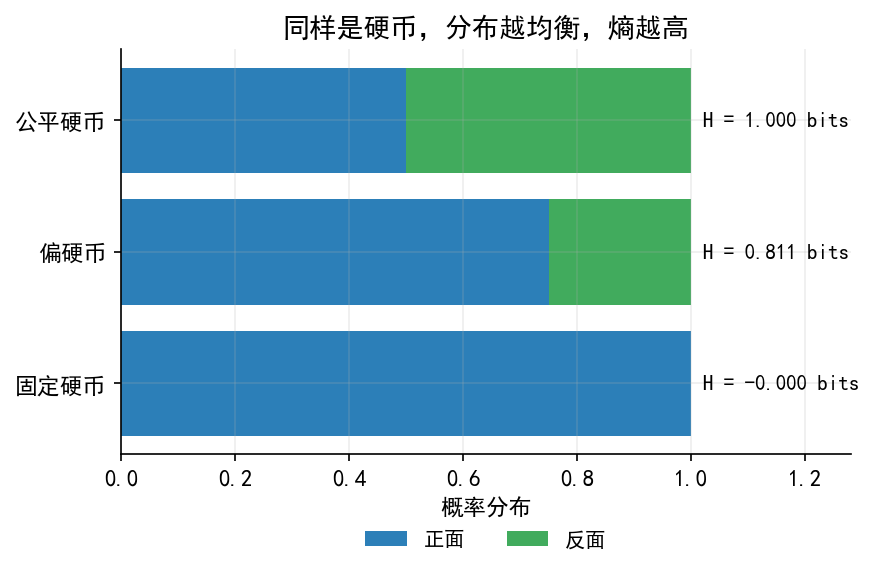

已保存: figs\entropy_intro_fig03_coin_examples.png


In [33]:
# 图 3：三个硬币例子。用紧凑的横向条形图展示概率分布与熵。
examples = pd.DataFrame({
    'example': ['公平硬币', '偏硬币', '固定硬币'],
    'P(head)': [0.50, 0.75, 1.00],
    'P(tail)': [0.50, 0.25, 0.00],
})
examples['H'] = examples.apply(lambda r: entropy([r['P(head)'], r['P(tail)']]), axis=1)
examples.to_csv(DATA_DIR / 'entropy_intro_coin_examples.csv', index=False, encoding='utf-8-sig')

fig, ax = plt.subplots(figsize=(6.0, 4.0))
y = np.arange(len(examples))
ax.barh(y, examples['P(head)'], color=COLORS['blue'], label='正面')
ax.barh(y, examples['P(tail)'], left=examples['P(head)'], color=COLORS['green'], label='反面')

for i, row in examples.iterrows():
    ax.text(1.02, i, f"H = {row['H']:.3f} bits", va='center', fontsize=10)

ax.set_yticks(y)
ax.set_yticklabels(examples['example'])
ax.set_xlim(0, 1.28)

ax.set_xlabel('概率分布')
ax.set_title('同样是硬币，分布越均衡，熵越高')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.14), frameon=False, ncol=2)
ax.invert_yaxis()
savefig('entropy_intro_fig03_coin_examples.png')
